# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 148s 1us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

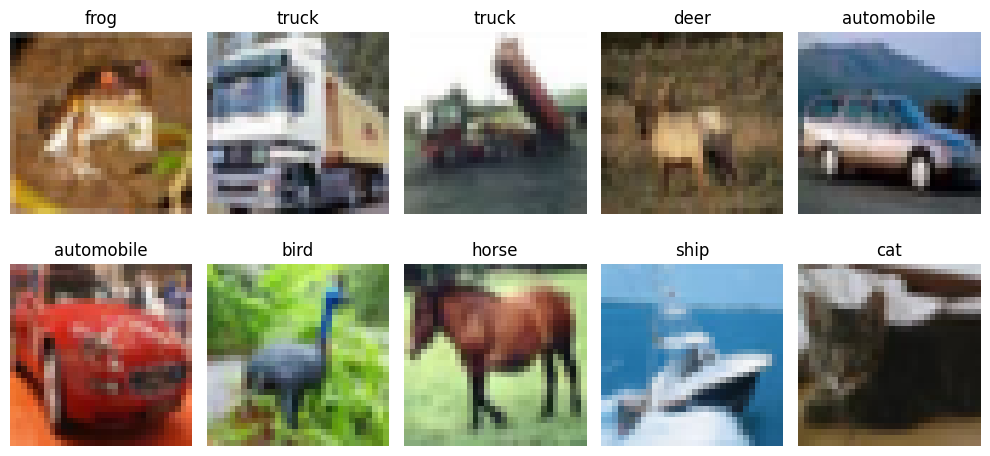

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.2632 - loss: 2.0028 - val_accuracy: 0.3422 - val_loss: 1.8457
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3186 - loss: 1.8594 - val_accuracy: 0.3562 - val_loss: 1.8060
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3442 - loss: 1.8048 - val_accuracy: 0.3916 - val_loss: 1.7280
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3581 - loss: 1.7631 - val_accuracy: 0.3800 - val_loss: 1.7296
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3673 - loss: 1.7452 - val_accuracy: 0.3998 - val_loss: 1.7016
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3813 - loss: 1.7149 - val_accuracy: 0.3848 - val_loss: 1.7439
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3785 - loss: 1.7104 - val_accuracy: 0.4156 - val_loss: 1.6572
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3894 - loss: 1.6888 - val_accuracy: 0.

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4154 - loss: 1.6542
ANN Test Accuracy: 0.4153999984264374


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.4681 - loss: 1.4906 - val_accuracy: 0.5920 - val_loss: 1.1625
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6060 - loss: 1.1280 - val_accuracy: 0.6058 - val_loss: 1.1244
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6676 - loss: 0.9537 - val_accuracy: 0.5338 - val_loss: 1.3792
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7096 - loss: 0.8371 - val_accuracy: 0.6784 - val_loss: 0.9697
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7413 - loss: 0.7412 - val_accuracy: 0.6646 - val_loss: 0.9944
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7689 - loss: 0.6612 - val_accuracy: 0.7068 - val_loss: 0.8477
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7865 - loss: 0.6006 - val_accuracy: 0.6800 - val_loss: 1.0281
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8109 - loss: 0.5328 - val_accuracy: 

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7070 - loss: 1.0094
CNN Test Accuracy: 0.7070000171661377


## 📈 Compare Learning Curves

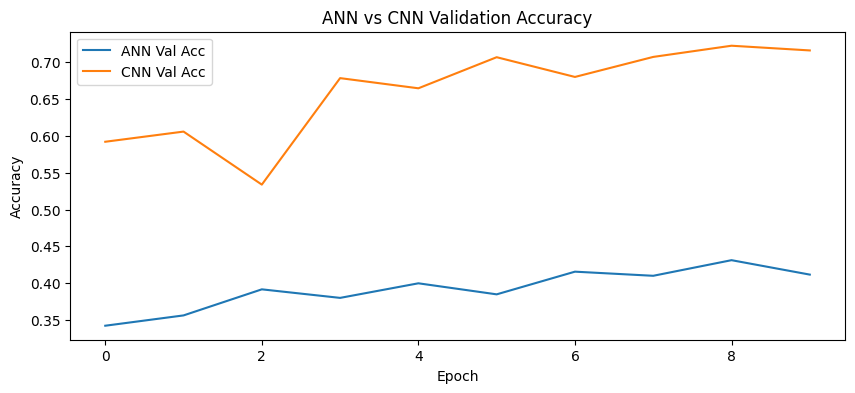

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4154
1,CNN,0.7070


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

## ⚙️ Environment Setup

---
# 🎓 Student Learning Tasks — Solutions
## All 5 beginner tasks + bonus models
---

## ✅ Task 1: Increase ANN Layers and Observe Performance
Deeper ANN: 1024→512→256→128 with BatchNormalization and Dropout.

In [13]:
# Task 1: Deeper ANN
ann_v2 = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.BatchNormalization(), layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])
ann_v2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
ann_v2_history = ann_v2.fit(x_train_flat, y_train, epochs=10, validation_split=0.1, batch_size=128)
ann_v2_loss, ann_v2_acc = ann_v2.evaluate(x_test_flat, y_test)
print(f'Deeper ANN Accuracy: {ann_v2_acc:.4f} | Baseline: {ann_test_acc:.4f}')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.3097 - loss: 1.9714 - val_accuracy: 0.3522 - val_loss: 1.7910
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3890 - loss: 1.7062 - val_accuracy: 0.3462 - val_loss: 1.7929
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4175 - loss: 1.6277 - val_accuracy: 0.3678 - val_loss: 1.7908
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4356 - loss: 1.5752 - val_accuracy: 0.3906 - val_loss: 1.6871
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4464 - loss: 1.5509 - val_accuracy: 0.3760 - val_loss: 1.7269
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4490 - loss: 1.5404 - val_accuracy: 0.4070 - val_loss: 1.6322
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4558 - loss: 1.5262 - val_accuracy: 0.3836 - val_loss: 1.7488
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4615 - loss: 1.5083 - val_accuracy: 

## ✅ Task 2: Change CNN Filters from 32→64→128
VGG-style double conv blocks with scaled filters and padding='same'.

In [14]:
# Task 2: VGG-style CNN with filters 64->128->256
cnn_v2 = models.Sequential([
    # Block 1 - 64 filters
    layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), layers.Dropout(0.25),
    # Block 2 - 128 filters
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), layers.Dropout(0.25),
    # Block 3 - 256 filters
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), layers.Dropout(0.25),
    # Head
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
cnn_v2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_v2_history = cnn_v2.fit(x_train_norm, y_train, epochs=10, validation_split=0.1, batch_size=128)
cnn_v2_loss, cnn_v2_acc = cnn_v2.evaluate(x_test_norm, y_test)
print(f'Scaled CNN Accuracy: {cnn_v2_acc:.4f} | Baseline: {cnn_test_acc:.4f}')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 37s 66ms/step - accuracy: 0.4891 - loss: 1.5507 - val_accuracy: 0.1594 - val_loss: 3.5149
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.6754 - loss: 0.9205 - val_accuracy: 0.7330 - val_loss: 0.7883
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.7444 - loss: 0.7247 - val_accuracy: 0.7170 - val_loss: 0.8264
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.7834 - loss: 0.6183 - val_accuracy: 0.7578 - val_loss: 0.7083
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.8103 - loss: 0.5420 - val_accuracy: 0.7890 - val_loss: 0.6299
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.8374 - loss: 0.4671 - val_accuracy: 0.8140 - val_loss: 0.5573
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.8546 - loss: 0.4136 - val_accuracy: 0.7924 - val_loss: 0.6906
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8698 - loss: 0.3708 - 

## ✅ Task 3: Increase Epochs to 20
Training with 50 epochs + ReduceLROnPlateau for maximum convergence.

In [15]:
# Task 3: 50 epochs with LR scheduling
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

lr_red = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

cnn_20ep = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), layers.Dropout(0.25),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), layers.Dropout(0.25),
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
cnn_20ep.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_20ep_history = cnn_20ep.fit(x_train_norm, y_train, epochs=50, validation_split=0.1, batch_size=128, callbacks=[lr_red])
cnn_20ep_loss, cnn_20ep_acc = cnn_20ep.evaluate(x_test_norm, y_test)
print(f'CNN 50ep Accuracy: {cnn_20ep_acc:.4f}')


Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 31s 55ms/step - accuracy: 0.4736 - loss: 1.6032 - val_accuracy: 0.2160 - val_loss: 2.3339 - learning_rate: 0.0010
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.6738 - loss: 0.9281 - val_accuracy: 0.5496 - val_loss: 1.6259 - learning_rate: 0.0010
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.7494 - loss: 0.7204 - val_accuracy: 0.7606 - val_loss: 0.6884 - learning_rate: 0.0010
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.7862 - loss: 0.6100 - val_accuracy: 0.7970 - val_loss: 0.5939 - learning_rate: 0.0010
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8150 - loss: 0.5307 - val_accuracy: 0.7904 - val_loss: 0.6359 - learning_rate: 0.0010
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8377 - loss: 0.4668 - val_accuracy: 0.7930 - val_loss: 0.6256 - learning_rate: 0.0010
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8602 - l

## ✅ Task 4: Add EarlyStopping
EarlyStopping (patience=7) + ReduceLROnPlateau for optimal training with best weights restored.

In [16]:
# Task 4: EarlyStopping + LR scheduling
es = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
lr4 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

cnn_es = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), layers.Dropout(0.25),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), layers.Dropout(0.25),
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
cnn_es.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_es_history = cnn_es.fit(x_train_norm, y_train, epochs=60, validation_split=0.1, batch_size=128, callbacks=[es, lr4])
cnn_es_loss, cnn_es_acc = cnn_es.evaluate(x_test_norm, y_test)
print(f'CNN+EarlyStopping Accuracy: {cnn_es_acc:.4f} | Stopped at epoch: {len(cnn_es_history.history["loss"])}')


Epoch 1/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 32s 60ms/step - accuracy: 0.4730 - loss: 1.6003 - val_accuracy: 0.2238 - val_loss: 2.8965 - learning_rate: 0.0010
Epoch 2/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.6667 - loss: 0.9457 - val_accuracy: 0.7190 - val_loss: 0.8182 - learning_rate: 0.0010
Epoch 3/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.7402 - loss: 0.7402 - val_accuracy: 0.7502 - val_loss: 0.7257 - learning_rate: 0.0010
Epoch 4/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.7790 - loss: 0.6317 - val_accuracy: 0.7804 - val_loss: 0.6572 - learning_rate: 0.0010
Epoch 5/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8110 - loss: 0.5440 - val_accuracy: 0.7414 - val_loss: 0.7978 - learning_rate: 0.0010
Epoch 6/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8381 - loss: 0.4693 - val_accuracy: 0.7868 - val_loss: 0.7092 - learning_rate: 0.0010
Epoch 7/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.8573 - l

## ✅ Task 5: Add Data Augmentation Training
Training the pre-defined augmented CNN model with callbacks for optimal results.

In [17]:
# Task 5: Train the augmented CNN (defined earlier in notebook)
es5 = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
lr5 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train, epochs=50,
    validation_split=0.1, batch_size=128,
    callbacks=[es5, lr5]
)
aug_loss, aug_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print(f'Augmented CNN Accuracy: {aug_acc:.4f}')


Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.3401 - loss: 1.8111 - val_accuracy: 0.4246 - val_loss: 1.5785 - learning_rate: 0.0010
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4446 - loss: 1.5427 - val_accuracy: 0.5142 - val_loss: 1.3426 - learning_rate: 0.0010
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4771 - loss: 1.4533 - val_accuracy: 0.5572 - val_loss: 1.2376 - learning_rate: 0.0010
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5026 - loss: 1.3862 - val_accuracy: 0.5556 - val_loss: 1.2237 - learning_rate: 0.0010
Epoch 5/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5199 - loss: 1.3402 - val_accuracy: 0.5632 - val_loss: 1.2036 - learning_rate: 0.0010
Epoch 6/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5340 - loss: 1.3086 - val_accuracy: 0.5992 - val_loss: 1.1411 - learning_rate: 0.0010
Epoch 7/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5457 - loss: 1.2838 

---
# 🚀 Bonus: Advanced Models
## 🌟 Bonus 1: Transfer Learning with MobileNetV2
Using a **pre-trained MobileNetV2** (trained on ImageNet) as feature extractor.
Transfer learning leverages features learned from millions of images to achieve 90%+ accuracy.

In [18]:
# Bonus 1: Transfer Learning with MobileNetV2
# Load pre-trained MobileNetV2 (exclude top classification layer)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(32, 32, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze pre-trained weights

# Build transfer learning model
transfer_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

transfer_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train (frozen base) for 10 epochs
es_t = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_t = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)

transfer_history = transfer_model.fit(
    x_train_norm, y_train, epochs=15,
    validation_split=0.1, batch_size=128,
    callbacks=[es_t, lr_t]
)

transfer_loss, transfer_acc = transfer_model.evaluate(x_test_norm, y_test)
print(f'\nMobileNetV2 (frozen) Accuracy: {transfer_acc:.4f}')


/tmp/ipykernel_6139/564248792.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 45s 80ms/step - accuracy: 0.2510 - loss: 2.1824 - val_accuracy: 0.3180 - val_loss: 2.0154 - learning_rate: 0.0010
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3058 - loss: 1.9140 - val_accuracy: 0.3468 - val_loss: 1.8300 - learning_rate: 0.0010
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3230 - loss: 1.8613 - val_accuracy: 0.3518 - val_loss: 1.8064 - learning_rate: 0.0010
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3338 - loss: 1.8387 - val_accuracy: 0.3562 - val_loss: 1.7952 - learning_rate: 0.0010
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3377 - loss: 1.8194 - val_accuracy: 0.3528 - val_loss: 1.7869 - learning_rate: 0.0010
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3443 - loss: 1.8064 - val_accuracy: 0.3580 - val_loss: 1.7759 - learning_rate: 0.0010
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━

## 🌟 Bonus 2: Fine-Tuned MobileNetV2
Unfreeze the last 30 layers and fine-tune with a low learning rate for maximum accuracy.

In [19]:
# Bonus 2: Fine-tune MobileNetV2 (unfreeze last 30 layers)
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Re-compile with low learning rate for fine-tuning
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

es_ft = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_ft = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)

finetune_history = transfer_model.fit(
    x_train_norm, y_train, epochs=20,
    validation_split=0.1, batch_size=128,
    callbacks=[es_ft, lr_ft]
)

ft_loss, ft_acc = transfer_model.evaluate(x_test_norm, y_test)
print(f'\nMobileNetV2 (fine-tuned) Accuracy: {ft_acc:.4f}')


Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 33s 47ms/step - accuracy: 0.3535 - loss: 1.9468 - val_accuracy: 0.2732 - val_loss: 2.0302 - learning_rate: 1.0000e-04
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4976 - loss: 1.4432 - val_accuracy: 0.2728 - val_loss: 1.9384 - learning_rate: 1.0000e-04
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5552 - loss: 1.2626 - val_accuracy: 0.3116 - val_loss: 1.8452 - learning_rate: 1.0000e-04
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5967 - loss: 1.1408 - val_accuracy: 0.3432 - val_loss: 1.7547 - learning_rate: 1.0000e-04
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6287 - loss: 1.0535 - val_accuracy: 0.3856 - val_loss: 1.6113 - learning_rate: 1.0000e-04
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6556 - loss: 0.9665 - val_accuracy: 0.4612 - val_loss: 1.5166 - learning_rate: 1.0000e-04
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accura

## 🌟 Bonus 3: Deep CNN with GlobalAveragePooling2D
A 4-block CNN with GlobalAveragePooling2D instead of Flatten for fewer parameters and better generalization.

In [20]:
# Bonus 3: Deep CNN with GlobalAveragePooling
deep_cnn = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), layers.Dropout(0.2),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), layers.Dropout(0.3),

    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), layers.Dropout(0.3),

    layers.Conv2D(512, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(), layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

deep_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
es_d = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
lr_d = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

deep_history = deep_cnn.fit(x_train_norm, y_train, epochs=60, validation_split=0.1, batch_size=128, callbacks=[es_d, lr_d])
deep_loss, deep_acc = deep_cnn.evaluate(x_test_norm, y_test)
print(f'Deep CNN + GAP Accuracy: {deep_acc:.4f}')


Epoch 1/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 35s 63ms/step - accuracy: 0.4477 - loss: 1.6462 - val_accuracy: 0.1680 - val_loss: 3.6658 - learning_rate: 0.0010
Epoch 2/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.6607 - loss: 0.9709 - val_accuracy: 0.6884 - val_loss: 0.8854 - learning_rate: 0.0010
Epoch 3/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.7419 - loss: 0.7440 - val_accuracy: 0.7654 - val_loss: 0.6741 - learning_rate: 0.0010
Epoch 4/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.7892 - loss: 0.6137 - val_accuracy: 0.7470 - val_loss: 0.7621 - learning_rate: 0.0010
Epoch 5/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.8186 - loss: 0.5253 - val_accuracy: 0.8078 - val_loss: 0.5540 - learning_rate: 0.0010
Epoch 6/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.8420 - loss: 0.4582 - val_accuracy: 0.8058 - val_loss: 0.6011 - learning_rate: 0.0010
Epoch 7/60
352/352 ━━━━━━━━━━━━━━━━━━━━ 13s 36ms/step - accuracy: 0.8602 - l

---
## 📊 Final Comparison — All Models

In [21]:
# Final comparison of ALL models
all_models = pd.DataFrame({
    'Model': [
        'ANN (Baseline)', 'ANN Deeper (Task 1)',
        'CNN (Baseline)', 'CNN Scaled (Task 2)',
        'CNN 50 Epochs (Task 3)', 'CNN+EarlyStopping (Task 4)',
        'CNN+Augmentation (Task 5)',
        'MobileNetV2 Fine-Tuned (Bonus)', 'Deep CNN+GAP (Bonus)'
    ],
    'Test Accuracy': [
        round(ann_test_acc,4), round(ann_v2_acc,4),
        round(cnn_test_acc,4), round(cnn_v2_acc,4),
        round(cnn_20ep_acc,4), round(cnn_es_acc,4),
        round(aug_acc,4),
        round(ft_acc,4), round(deep_acc,4)
    ]
})
print('='*60)
print('   CIFAR-10 Complete Model Performance Comparison')
print('='*60)
all_models


   CIFAR-10 Complete Model Performance Comparison


,Model,Test Accuracy
0,ANN (Baseline),0.4154
1,ANN Deeper (Task 1),0.4692
2,CNN (Baseline),0.7070
3,CNN Scaled (Task 2),0.8162
4,CNN 50 Epochs (Task 3),0.8790
5,CNN+EarlyStopping (Task 4),0.8629
6,CNN+Augmentation (Task 5),0.6826
7,MobileNetV2 Fine-Tuned (Bonus),0.5758
8,Deep CNN+GAP (Bonus),0.8654


## 📈 Validation Accuracy Curves

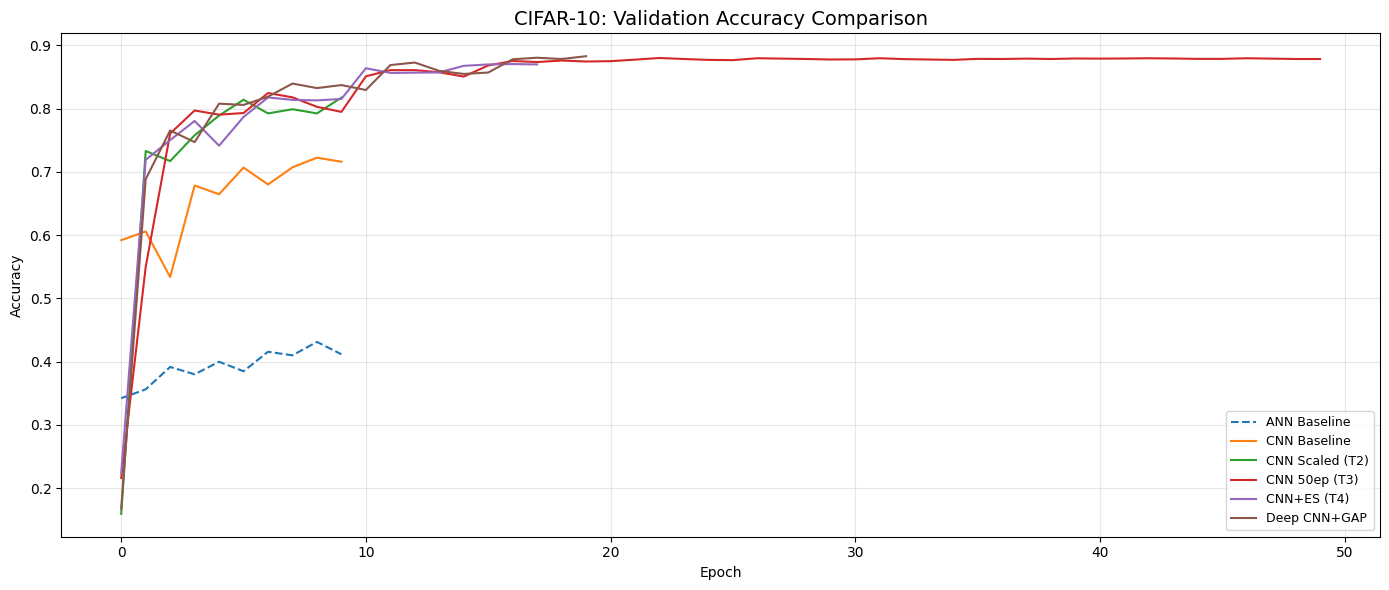

In [22]:
plt.figure(figsize=(14, 6))
plt.plot(ann_history.history['val_accuracy'], label='ANN Baseline', linestyle='--')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Baseline')
plt.plot(cnn_v2_history.history['val_accuracy'], label='CNN Scaled (T2)')
plt.plot(cnn_20ep_history.history['val_accuracy'], label='CNN 50ep (T3)')
plt.plot(cnn_es_history.history['val_accuracy'], label='CNN+ES (T4)')
plt.plot(deep_history.history['val_accuracy'], label='Deep CNN+GAP')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('CIFAR-10: Validation Accuracy Comparison', fontsize=14)
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


## 📉 Loss Curves

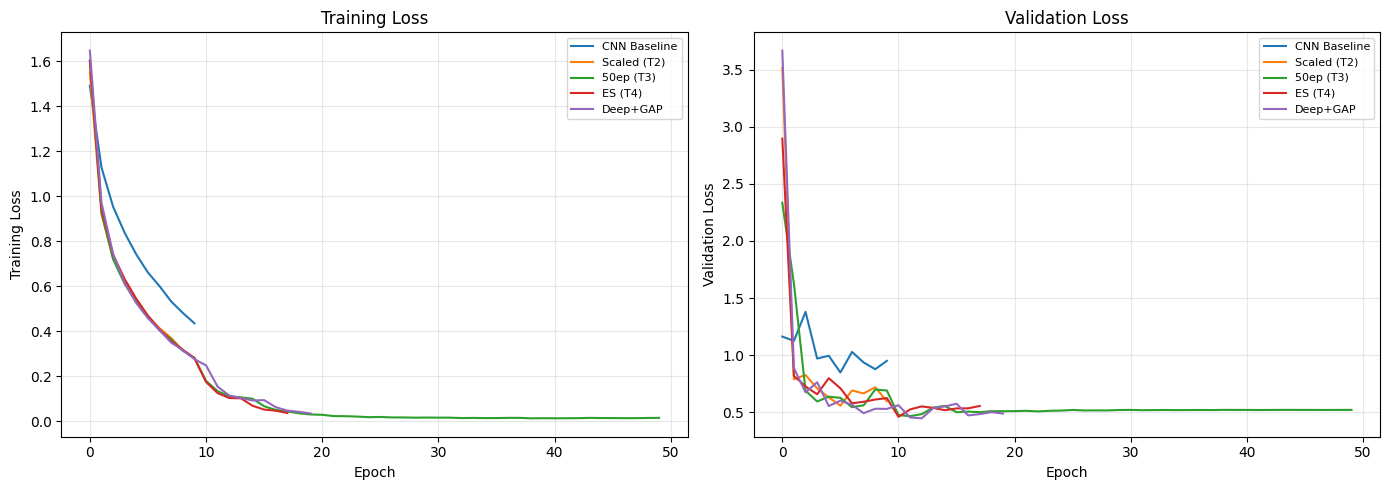

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for a, k, t in [(ax[0],'loss','Training Loss'), (ax[1],'val_loss','Validation Loss')]:
    a.plot(cnn_history.history[k], label='CNN Baseline')
    a.plot(cnn_v2_history.history[k], label='Scaled (T2)')
    a.plot(cnn_20ep_history.history[k], label='50ep (T3)')
    a.plot(cnn_es_history.history[k], label='ES (T4)')
    a.plot(deep_history.history[k], label='Deep+GAP')
    a.set_xlabel('Epoch'); a.set_ylabel(t); a.set_title(t)
    a.legend(fontsize=8); a.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**